In [1]:
# Inverse scheme reattack.
# By: Ligang Sun.
# Date: 04/17/2025.
# You reap what you sow.
# Goal of this file: complete the workflow with higher dimension searching space.

In [2]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

In [3]:
jcm_optimizer_path = "/home/sun2024/JCMoptimizer"
sys.path.insert(0, os.path.join(jcm_optimizer_path, "interface", "python"))
from jcmoptimizer import Server, Client, Study, Observation

In [4]:
from forward_model import ForwardModel
from forward_model.modules import ConfigParameter

In [5]:
# Statement of the problem.
thetaarray=np.linspace(-20,30,6) # for now we still use the simple Reference 1.

# source definition: unit m.
lambda0=1e-9 #**********************************check!!
# geometry: unit in m.
pitch=80e-9
line=40e-9
height=30e-9
thickness=1e-3 # substrate with thickness being 1mm.
rr=5 # sample detector distance in m.
# material parameter.
epsilonr1=0.99964+0.0000295399j # grating structure************check!!
epsilonr2=0.999435 # substrate********************check!!

dimqxbranch=5 # number of interested Qx peak per branch.
diroutput="/home/sun2024/Resource/JCM/Inverse_2D/simulation2a/Reference1/Output_all"

config=ConfigParameter(pitch, line, height, thickness, rr, epsilonr1, epsilonr2, lambda0, dimqxbranch)

In [6]:
# Forward model initialization.
fm=ForwardModel(config, Multiplicity=1, NThreads=6)

In [7]:
# Part 1: generate numerical reference.
Qzdomain, intref, intuncertainty =fm.CompRef(thetaarray,config,diroutput)

current thata :  -20.0
matmeta generated.
Numerical reference generated.


In [8]:
# Part 2: intensity with an arbitray initial guess. The real case.
initguess={'cd':28, 'h': 32}
intrandom=fm.ModelEvaluate(keys=initguess,config=config)

current thata :  -20.0
current thata :  -10.0
current thata :  0.0
current thata :  10.0
current thata :  20.0
current thata :  30.0
{'IP': '0.0.0.0',
 'Jobs': {'Finished': [],
          'Pending': [],
          'ReceivingData': [],
          'Running': [1672505107],
          'SendingData': [],
          'Waiting': [1230167561,
                      1948604556,
                      138545679,
                      1756440730,
                      1186681655]},
 'Port': 33995}
All status {'IP': '0.0.0.0', 'Port': 33995, 'Jobs': {'Finished': [], 'Pending': [], 'ReceivingData': [], 'Running': [1672505107], 'SendingData': [], 'Waiting': [1230167561, 1948604556, 138545679, 1756440730, 1186681655]}}
All logs saved in /home/sun2024/Resource/JCM/Inverse_2D/simulation2a/forward_model/jcm/logs_all.txt.
matmeta generated.
Forward model evaluated.
2025-04-17 23:32:24: Polling server at http://localhost:4554
2025-04-17 23:32:25: Optimization server is running
2025-04-17 23:32:33: The dashboard i

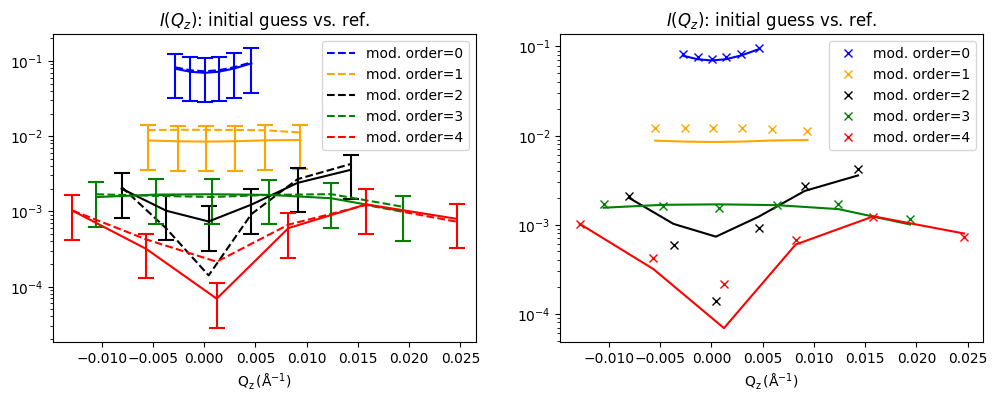

In [43]:
# Initial guess vs. reference.
colorarray=['blue','orange','black','green','red']
plt.figure(figsize=(12, 4))

plt.subplot(1,2,1)
for i in range(config.dimqxbranch):
    qzarray=Qzdomain[:,i]
    intrefarray=intref[:,i]
    uncertainarray=intuncertainty[:, i]
    intmodarray=intrandom[:,i]
    plt.errorbar(qzarray, intrefarray, yerr=uncertainarray, fmt='-', elinewidth=1.5, capsize=6, capthick=1.5,color=colorarray[i])
    plt.plot(qzarray, intmodarray,'--', markersize=5, label=f'mod. order={i}', color=colorarray[i])

plt.xlabel(r'$\mathrm{Q_z} \, (\mathrm{\AA}^{-1})$')
plt.ylabel('')
plt.yscale('log')
plt.title(rf'$I(Q_z)$: initial guess vs. ref.')
plt.legend()
#plt.grid()

plt.subplot(1,2,2)
for i in range(intref.shape[1]):
    qzarray=Qzdomain[:,i]
    intrefarray=intref[:,i]
    uncertainarray=intuncertainty[:, i]
    intmodarray=intrandom[:,i]
    plt.plot(qzarray, intrefarray,'-', color=colorarray[i])
    plt.plot(qzarray, intmodarray,'x', markersize=6, label=f'mod. order={i}', color=colorarray[i])

plt.xlabel(r'$\mathrm{Q_z} \, (\mathrm{\AA}^{-1})$')
plt.ylabel('')
plt.yscale('log')
plt.title(rf'$I(Q_z)$: initial guess vs. ref.')
plt.legend()
#plt.grid()

plt.show()

In [16]:
# Relative error report:
print("Relative error report:")
rltverrarray=[]
for i in range(config.dimqxbranch):
    array1=intref[:,i]
    array2=intrandom[:,i]
    rltverr=np.linalg.norm(array1-array2)/np.linalg.norm(array1)
    rltverrarray.append(rltverr)
    print(f"relative error of the {i+1}th peak, {rltverr:.2f}")
print(f"Overall relative error: {np.mean(rltverrarray):.2f}")

In [14]:
# Very good!!

In [9]:
# Part 3: Bayesian optimization.
#start server and connect client to it
server = Server()
client = Client(server.host)

In [10]:
# define search space.
design_space = [
 {'name': 'cd', 'domain': [28, 33]},
 {'name': 'h', 'domain': [27, 32]}
]
param_names = {param['name'] : '${' + '}_{\\rm '.join(param['name'].split('_')) + '}$' for param in design_space}

# define fixed parameter.
environment = [
{'name': 'pitch', 'type': 'fixed', 'domain': 80},
{'name': 'swa', 'type': 'fixed', 'domain': 71.56505117707799},
{'name': 'r_top', 'type': 'fixed', 'domain': 8.0},
{'name': 'r_bot', 'type': 'fixed', 'domain': 5.0}
]

# Before, constraints were met if they are smaller or equal zero. Now this is defined as unequality signs "<=" or ">="
# Key 'constraint' key was renamed to 'expression'
constraints = [
 {'name': 'r_top', 'expression': 'r_top + h/2/tan(PI*swa/180) <= cd/2 - 1'},
 {'name': 'r_bot', 'expression': 'r_bot + cd/2 + h/2/tan(PI*swa/180) <= pitch/2 - 1'},
 {'name': 'r_bot_t', 'expression': 'r_bot + cd/2 + h/2/tan(PI*swa/180) <= pitch/2 - 1'}
]

In [11]:
study = client.create_study(
    design_space=design_space,
    environment=environment,
    constraints=constraints,
    driver="BayesianLeastSquares",
    name="ParaRecon102",
    study_id="pararecon_attack_102", 
    save_dir=os.getcwd()
)

In [12]:
target_vector=[*[value for i in range(config.dimqxbranch) for value in intref[:, i]]]
uncertainty_vector=[*[value for i in range(config.dimqxbranch) for value in intuncertainty[:, i]]]

In [13]:
#study.set_parameters renamed to study.configure
study.configure(
    max_iter=10, target_vector=target_vector,
    uncertainty_vector=uncertainty_vector
)

In [14]:
#objective renamed to evaluator
def evaluate(study, **kwargs):
    observation = study.new_observation()
    intmod = fm.ModelEvaluate(kwargs,config=config)
    observation.add([
        *[value for i in range(config.dimqxbranch) for value in intmod[:, i]]     
    ])
    return observation
study.set_evaluator(evaluate)

In [15]:
study.run()

In [17]:
best_sample = study.driver.best_sample
min_chisq = study.driver.min_objective
uncertainties = study.driver.uncertainties
print(f"Reconstructed parameters with chi-squared value {min_chisq:.4e}:")
for param in design_space:
    name = param['name']
    print(f"  {name} = {best_sample[name]:.3f} +/- {uncertainties[name]:.3f}")

In [18]:
print(best_sample)

In [19]:
intopt=fm.ModelEvaluate(keys=best_sample,config=config)

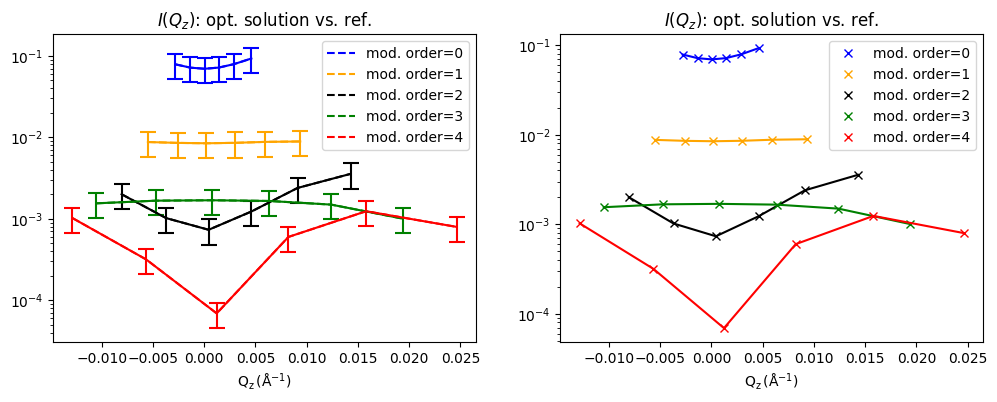

In [21]:
# Optimized solution vs. reference.
colorarray=['blue','orange','black','green','red']
plt.figure(figsize=(12, 4))

plt.subplot(1,2,1)
for i in range(config.dimqxbranch):
    qzarray=Qzdomain[:,i]
    intrefarray=intref[:,i]
    uncertainarray=intuncertainty[:, i]
    intmodarray=intopt[:,i]
    plt.errorbar(qzarray, intrefarray, yerr=uncertainarray, fmt='-', elinewidth=1.5, capsize=6, capthick=1.5,color=colorarray[i])
    plt.plot(qzarray, intmodarray,'--', markersize=5, label=f'mod. order={i}', color=colorarray[i])

plt.xlabel(r'$\mathrm{Q_z} \, (\mathrm{\AA}^{-1})$')
plt.ylabel('')
plt.yscale('log')
plt.title(rf'$I(Q_z)$: opt. solution vs. ref.')
plt.legend()

plt.subplot(1,2,2)
for i in range(intref.shape[1]):
    qzarray=Qzdomain[:,i]
    intrefarray=intref[:,i]
    uncertainarray=intuncertainty[:, i]
    intmodarray=intopt[:,i]
    plt.plot(qzarray, intrefarray,'-', color=colorarray[i])
    plt.plot(qzarray, intmodarray,'x', markersize=6, label=f'mod. order={i}', color=colorarray[i])

plt.xlabel(r'$\mathrm{Q_z} \, (\mathrm{\AA}^{-1})$')
plt.ylabel('')
plt.yscale('log')
plt.title(rf'$I(Q_z)$: opt. solution vs. ref.')
plt.legend()

plt.show()

In [23]:
# Relative error report:
print("Relative error report:")
rltverrarray=[]
for i in range(config.dimqxbranch):
    array1=intref[:,i]
    array2=intopt[:,i]
    rltverr=np.linalg.norm(array1-array2)/np.linalg.norm(array1)
    rltverrarray.append(rltverr)
    print(f"relative error of the {i+1}th peak, {rltverr:.2f}")
print(f"Overall relative error: {np.mean(rltverrarray):.2f}")

In [24]:
# Part 4: extra check with the true solution.
truesol={'cd':30, 'h': 30}
intsol=fm.ModelEvaluate(keys=truesol,config=config)

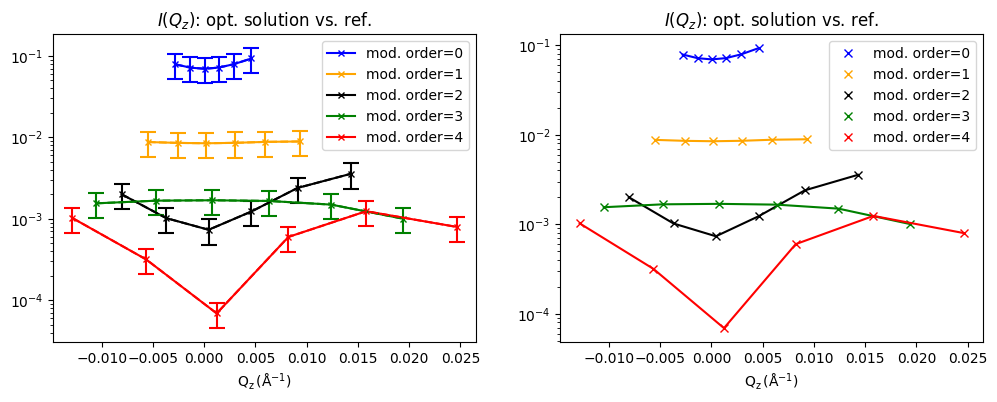

In [27]:
# True solution vs. reference.
colorarray=['blue','orange','black','green','red']
plt.figure(figsize=(12, 4))

plt.subplot(1,2,1)
for i in range(config.dimqxbranch):
    qzarray=Qzdomain[:,i]
    intrefarray=intref[:,i]
    uncertainarray=intuncertainty[:, i]
    intmodarray=intsol[:,i]
    plt.errorbar(qzarray, intrefarray, yerr=uncertainarray, fmt='--', elinewidth=1.5, capsize=6, capthick=1.5,color=colorarray[i])
    plt.plot(qzarray, intmodarray,'-x', markersize=5, label=f'mod. order={i}', color=colorarray[i])

plt.xlabel(r'$\mathrm{Q_z} \, (\mathrm{\AA}^{-1})$')
plt.ylabel('')
plt.yscale('log')
plt.title(rf'$I(Q_z)$: opt. solution vs. ref.')
plt.legend()

plt.subplot(1,2,2)
for i in range(intref.shape[1]):
    qzarray=Qzdomain[:,i]
    intrefarray=intref[:,i]
    uncertainarray=intuncertainty[:, i]
    intmodarray=intsol[:,i]
    plt.plot(qzarray, intrefarray,'-', color=colorarray[i])
    plt.plot(qzarray, intmodarray,'x', markersize=6, label=f'mod. order={i}', color=colorarray[i])

plt.xlabel(r'$\mathrm{Q_z} \, (\mathrm{\AA}^{-1})$')
plt.ylabel('')
plt.yscale('log')
plt.title(rf'$I(Q_z)$: opt. solution vs. ref.')
plt.legend()

plt.show()

In [28]:
# Relative error report:
print("Relative error report:")
rltverrarray=[]
for i in range(config.dimqxbranch):
    array1=intref[:,i]
    array2=intsol[:,i]
    rltverr=np.linalg.norm(array1-array2)/np.linalg.norm(array1)
    rltverrarray.append(rltverr)
    print(f"relative error of the {i+1}th peak, {rltverr:.2f}")
print(f"Overall relative error: {np.mean(rltverrarray):.2f}")